# Fine-Tuning GPT-2 on a Custom Text Style

**Name:** Varshith Kumar R


**Class:** BCA


**Goal:** show how fine-tuning adapts a pretrained GPT-2 (small, 124M) to a specific writing style.

**Dataset:** 211 lines of original writing in the style of an old-fashioned **sea captain's logbook** (formal, nautical, first-person, similes and sea imagery).

**Pipeline:** raw data → cleaning → tokenisation → fine-tune with Hugging Face `Trainer` → generate from base and fine-tuned models with the *same prompt and seed* → compare.

> Run on Google Colab with a GPU (Runtime → Change runtime type → T4 GPU) for fast training. It also runs on CPU, just slower.

In [1]:
!pip install -q transformers datasets accelerate

## 1. Original (raw) dataset
The raw file deliberately contains timestamps, usernames and stray whitespace, which the next step removes. It is saved as `raw_dataset.txt` for submission.

In [2]:
RAW_TEXT = """[Log #001 | 05:07] <Mr_Finch>  The sea was grey as an old nail this morning, and the wind came sharp from the north.
[Log #002 | 05:14] <Capt_Hale>  We weighed anchor at first light, and the crew sang low as the capstan turned.
[Log #003 | 05:21] <Capt_Hale>  Not a gull in the sky, which any sailor will tell you is a poor omen.
[Log #004 | 05:28] <Capt_Hale>  I have marked our position on the chart and said a quiet word to the compass.
[Log #005 | 05:35] <Capt_Hale>  The cook swears the biscuits are fresh, but the weevils say otherwise.
[Log #006 | 05:42] <Capt_Hale>  Fair winds held through the forenoon, and the old ship groaned like a tired grandfather.
[Log #007 | 05:49] <Mr_Finch>  Mr. Finch reports a leak in the forward hold, and I have ordered the pumps manned.
[Log #008 | 05:56] <Capt_Hale>  A storm gathers on the horizon, dark as pitch, and the barometer falls like a stone.
[Log #009 | 05:03] <Capt_Hale>  We reefed the topsails and lashed down the cargo, for the sea shows no mercy to the careless.
[Log #010 | 05:10] <Capt_Hale>  The men are weary, yet not one has spoken a word of complaint.
[Log #011 | 05:17] <Capt_Hale>  By my reckoning we are three days from the southern cape, God and weather willing.
[Log #012 | 06:24] <Capt_Hale>  Tonight the stars burn bright as lanterns, and the helmsman steers by the Plough.
[Log #013 | 06:31] <Capt_Hale>  I confess a fondness for the night watch, when the ocean is all silver and silence.
[Log #014 | 06:38] <Capt_Hale>  The boy Tobias climbed the mainmast today without a single tremble, and I was proud of him.
[Log #015 | 06:45] <Capt_Hale>  We sighted a whale at noon, vast and slow, rolling like a hill come loose from the land.
[Log #016 | 06:52] <Capt_Hale>  The rum ration was doubled in honour of the captain's birthday, and the deck rang with laughter.
[Log #017 | 06:59] <Capt_Hale>  Salt has crept into everything, my boots, my journal, even my thoughts.
[Log #018 | 06:06] <Capt_Hale>  A cold fog swallowed the ship at dusk, and we rang the bell every quarter hour.
[Log #019 | 06:13] <Capt_Hale>  The lookout swore he saw a light off the starboard bow, but the dark gave nothing back.
[Log #020 | 06:20] <Capt_Hale>  I have long held that a ship is only as steady as the hands that sail her.
[Log #021 | 06:27] <Capt_Hale>  Morning came with a pale gold sky, and the sea lay flat as a polished plate.
[Log #022 | 06:34] <Capt_Hale>  We mended the torn mainsail by lantern light, stitch by patient stitch.
[Log #023 | 06:41] <Capt_Hale>  The carpenter says the mast will hold, and I have learned to trust his word over any chart.
[Log #024 | 07:48] <Capt_Hale>  Three flying fish landed on deck at breakfast, and the cook declared them a gift from Neptune himself.
[Log #025 | 07:55] <Capt_Hale>  There is a loneliness in the open water that no landsman could ever understand.
[Log #026 | 07:02] <Capt_Hale>  I wrote to my wife again tonight, though the letter shall not leave the ship for many weeks.
[Log #027 | 07:09] <Mr_Finch>  The crew gathered on the forecastle to hear old Mr. Pike tell of the drowned bell of Saint Elmo's Cove.
[Log #028 | 07:16] <Capt_Hale>  A strong current pushed us east, and I cursed it roundly before accepting its will.
[Log #029 | 07:23] <Capt_Hale>  By evening the clouds broke, and a rainbow stood over the water like a bridge to nowhere.
[Log #030 | 07:30] <Capt_Hale>  The rigging is frozen stiff with frost, and every rope bites the hand that holds it.
[Log #031 | 07:37] <Mr_Finch>  We lost a barrel of water overboard in the swell, and rationing begins at sunrise.
[Log #032 | 07:44] <Capt_Hale>  I have never trusted a calm that comes after a storm, for the sea is a patient liar.
[Log #033 | 07:51] <Capt_Hale>  The surgeon dressed young Davies's hand, and the lad whistled through the pain like a true seaman.
[Log #034 | 07:58] <Capt_Hale>  At dawn a small island rose from the mist, green and quiet, untouched by any chart I own.
[Log #035 | 07:05] <Mr_Finch>  We dropped anchor in the shallows and sent a boat ashore to seek fresh water.
[Log #036 | 08:12] <Capt_Hale>  The men returned with coconuts, wild figs and a stray goat, which the cook welcomed with great ceremony.
[Log #037 | 08:19] <Capt_Hale>  That night we feasted on the beach beneath a sky crowded with stars.
[Log #038 | 08:26] <Capt_Hale>  I cannot say why, but the island felt as if it were watching us.
[Log #039 | 08:33] <Capt_Hale>  We departed at first light, and I confess I did not look back.
[Log #040 | 08:40] <Capt_Hale>  The wind turned fickle after noon, and the sails flapped like the wings of a wounded bird.
[Log #041 | 08:47] <Capt_Hale>  Mr. Finch tells me the crew grows restless, so I have ordered a game of quoits on the quarterdeck.
[Log #042 | 08:54] <Mr_Finch>  The ocean tonight is black glass, and the moon walks across it in a trail of silver.
[Log #043 | 08:01] <Capt_Hale>  I once sailed with a captain who feared the sea; he never saw his second voyage's end.
[Log #044 | 08:08] <Capt_Hale>  Respect the water, I tell the boy, and she will carry you home.
[Log #045 | 08:15] <Mr_Finch>  A school of dolphins raced alongside the bow for an hour, leaping as if in joy.
[Log #046 | 08:22] <Mr_Finch>  The ship's cat caught a rat the size of a small dog, and was promoted to able seaman.
[Log #047 | 08:29] <Capt_Hale>  Our supply of salt pork is low, and the men look at it with deep suspicion.
[Log #048 | 09:36] <Capt_Hale>  I have drawn the coast of the new land as best I could, though the fog hid half its secrets.
[Log #049 | 09:43] <Capt_Hale>  We hailed a passing brig at noon and traded tobacco for two sacks of flour.
[Log #050 | 09:50] <Capt_Hale>  The captain of the brig spoke of pirates in the eastern waters, and I doubled the night watch.
[Log #051 | 09:57] <Mr_Finch>  Every creak of the timbers tonight sounds like a warning, though I cannot read its meaning.
[Log #052 | 09:04] <Capt_Hale>  The cook has burned the stew again, and the crew bore it with the patience of saints.
[Log #053 | 09:11] <Mr_Finch>  A fresh gale tore across the deck at midday, and we ran before it with all hands at the sheets.
[Log #054 | 09:18] <Capt_Hale>  I never knew the sea could be so loud until I stood beneath a breaking wave.
[Log #055 | 09:25] <Mr_Finch>  The foremast cracked in the night, and the whole ship shuddered as though she felt the wound.
[Log #056 | 09:32] <Capt_Hale>  We rigged a jury mast from a spare spar, and the carpenter swore a prayer over every nail.
[Log #057 | 09:39] <Capt_Hale>  The rain fell in sheets for six hours, and we drank it gladly from every bucket and cup.
[Log #058 | 09:46] <Capt_Hale>  My old bones ache with the damp, yet I would not trade this deck for a king's bed.
[Log #059 | 09:53] <Capt_Hale>  Tobias asked me today why the sea is salt, and I told him it is the tears of those left ashore.
[Log #060 | 10:00] <Mr_Finch>  The crew laughed at that, though I think old Pike wiped an eye.
[Log #061 | 10:07] <Capt_Hale>  A dull red sun rose through the haze, and the sailors muttered of ill weather to come.
[Log #062 | 10:14] <Capt_Hale>  They were right, as sailors always are about trouble.
[Log #063 | 10:21] <Capt_Hale>  By the second dog watch the wind had risen to a howl, and the ship bucked like a frightened horse.
[Log #064 | 10:28] <Capt_Hale>  We lashed ourselves to the rail and held on through the black heart of the night.
[Log #065 | 10:35] <Capt_Hale>  Dawn found us alive, battered, soaked, and strangely merry.
[Log #066 | 10:42] <Mr_Finch>  I counted heads at breakfast, and every one was there, which is the only treasure I seek.
[Log #067 | 10:49] <Mr_Finch>  The leak has worsened, and we pump in shifts of two hours, each man swearing at the next.
[Log #068 | 10:56] <Mr_Finch>  Land birds were seen at noon, and a hush of hope swept over the deck.
[Log #069 | 10:03] <Capt_Hale>  I climbed the shrouds myself at dusk and saw the faint grey line of the coast.
[Log #070 | 10:10] <Capt_Hale>  The men cheered so loudly that I feared the sails would tear.
[Log #071 | 10:17] <Capt_Hale>  We anchored in a sheltered bay, and the water was clear as a window down to the sand.
[Log #072 | 11:24] <Capt_Hale>  The harbour master came aboard at sunrise, a stout fellow with a beard like a bird's nest.
[Log #073 | 11:31] <Mr_Finch>  He asked our business, and I told him plainly: tea, timber and a little hope.
[Log #074 | 11:38] <Capt_Hale>  He laughed, stamped our papers, and bid us welcome in the name of his town.
[Log #075 | 11:45] <Capt_Hale>  We sold the cargo by afternoon at a fair price, and the crew was paid before supper.
[Log #076 | 11:52] <Capt_Hale>  I gave young Tobias an extra shilling, and he stared at it as though it were a star.
[Log #077 | 11:59] <Mr_Finch>  The men have gone ashore to taste the tavern's ale and the town's gossip.
[Log #078 | 11:06] <Capt_Hale>  I remain aboard, alone with the lamp, the log, and the slow rocking of the tide.
[Log #079 | 11:13] <Mr_Finch>  There is a peace in an empty ship that no harbour noise can break.
[Log #080 | 11:20] <Capt_Hale>  Tomorrow we take on stores and fresh hands, and the sea will call us once more.
[Log #081 | 11:27] <Mr_Finch>  I wrote today of the fog, the whale, and the island that watched us leave.
[Log #082 | 11:34] <Capt_Hale>  Some voyages are measured in miles, and some in the things we dare not say aloud.
[Log #083 | 11:41] <Capt_Hale>  The dawn wind was soft as a sigh, and we slipped out of port with the ebb tide.
[Log #084 | 12:48] <Mr_Finch>  A pilot boat led us past the rocks, and the lad at the tiller grinned like a fox.
[Log #085 | 12:55] <Capt_Hale>  The new hands are green but willing, and old Pike has taken them under his wing.
[Log #086 | 12:02] <Capt_Hale>  I have set the course for the northern straits, where the water runs cold and the whales run deep.
[Log #087 | 12:09] <Capt_Hale>  We shall be gone three months at least, and I have told the crew to write their letters now.
[Log #088 | 12:16] <Capt_Hale>  The ship feels lighter with a hold full of hope and an empty belly of regret.
[Log #089 | 12:23] <Capt_Hale>  At noon a squall crossed our bow, brief and bitter, and passed like a thief in the night.
[Log #090 | 12:30] <Mr_Finch>  The helmsman sings an old song of a drowned sailor, and the wind carries it away.
[Log #091 | 12:37] <Capt_Hale>  I have grown fond of this crew, as a man grows fond of weather he has survived.
[Log #092 | 12:44] <Capt_Hale>  The cook produced a plum pudding today, and no man dared ask where the plums had come from.
[Log #093 | 12:51] <Capt_Hale>  By lantern light I studied the charts and found a passage no one has marked.
[Log #094 | 12:58] <Capt_Hale>  Mr. Finch calls it folly; I call it opportunity wearing a poor coat.
[Log #095 | 12:05] <Capt_Hale>  We shall try it at first light, and let the sea render her verdict.
[Log #096 | 13:12] <Capt_Hale>  The night was cold and clear, and the stars hung so low I might have plucked them from the rigging.
[Log #097 | 13:19] <Capt_Hale>  Dawn came grey and wet, and the passage opened before us like a narrow door.
[Log #098 | 13:26] <Capt_Hale>  We crept through at half sail, with the leadsman calling the depth every minute.
[Log #099 | 13:33] <Capt_Hale>  Seven fathoms, six, then five, and my heart beat like a drum in a close room.
[Log #100 | 13:40] <Mr_Finch>  At last the water deepened, and the whole crew let out a breath they had held for an hour.
[Log #101 | 13:47] <Capt_Hale>  Beyond the strait lay a wide green sea, calm as a sleeping child.
[Log #102 | 13:54] <Capt_Hale>  I named the passage for my wife, and wrote it boldly on the chart.
[Log #103 | 13:01] <Mr_Finch>  The men drank to her health, and I pretended not to be moved.
[Log #104 | 13:08] <Capt_Hale>  A thin snow fell at dusk, and the deck turned white as a bridal gown.
[Log #105 | 13:15] <Mr_Finch>  Ice formed on the rigging, and the sailors beat it off with wooden mallets.
[Log #106 | 13:22] <Capt_Hale>  Our breath hung in the air like smoke, and every beard grew stiff with frost.
[Log #107 | 13:29] <Capt_Hale>  I have never known such cold, nor such silence, as in these northern waters.
[Log #108 | 14:36] <Capt_Hale>  We sighted a berg at noon, tall and blue, drifting past like a cathedral lost at sea.
[Log #109 | 14:43] <Capt_Hale>  The boy stared at it long, and I let him, for wonder is a rare cargo.
[Log #110 | 14:50] <Capt_Hale>  Mr. Pike says his grandfather once saw a ship made entirely of ice, and nobody believed him.
[Log #111 | 14:57] <Capt_Hale>  I believed him, for the sea has shown me stranger things.
[Log #112 | 14:04] <Capt_Hale>  The wind dropped at night, and we lay becalmed under a sky of green fire.
[Log #113 | 14:11] <Capt_Hale>  The sailors fell silent as the lights danced across the heavens.
[Log #114 | 14:18] <Capt_Hale>  I have no words for it, and so I leave this page almost blank.
[Log #115 | 14:25] <Capt_Hale>  In the morning a breeze returned, and we turned our bow toward the south.
[Log #116 | 14:32] <Capt_Hale>  The voyage home begins, and every man aboard walks a little taller.
[Log #117 | 14:39] <Mr_Finch>  We ran before a following wind for five days, and the ship fairly flew.
[Log #118 | 14:46] <Mr_Finch>  The log shows a hundred and ninety miles in one day, a record for this old hull.
[Log #119 | 14:53] <Capt_Hale>  Even the cat seemed pleased, and sat on the capstan like a small king.
[Log #120 | 15:00] <Capt_Hale>  I mended my pen tonight and thought of the garden at home, damp with evening dew.
[Log #121 | 15:07] <Capt_Hale>  The sea is generous to those who ask little and endure much.
[Log #122 | 15:14] <Mr_Finch>  A thin rain fell at dawn, and we welcomed it as one welcomes an old friend.
[Log #123 | 15:21] <Mr_Finch>  Mr. Finch has been unusually cheerful, and I suspect he has found a letter in his locker.
[Log #124 | 15:28] <Capt_Hale>  We exchanged signals with a passing frigate, and she dipped her flag in salute.
[Log #125 | 15:35] <Capt_Hale>  I returned the courtesy, though my flag was patched in three places.
[Log #126 | 15:42] <Capt_Hale>  Our water is low again, yet no man grumbles, for home is near.
[Log #127 | 15:49] <Capt_Hale>  The coast of our own country rose from the sea at sunset, purple and tender.
[Log #128 | 15:56] <Capt_Hale>  I stood at the rail a long while and said nothing to anyone.
[Log #129 | 15:03] <Capt_Hale>  The pilot came aboard at midnight, smelling of pipe smoke and wet wool.
[Log #130 | 15:10] <Capt_Hale>  He brought news of the harvest, the weather, and the price of tea, and I drank it all in.
[Log #131 | 15:17] <Capt_Hale>  We anchored at dawn in the familiar roads, and the church bells rang across the water.
[Log #132 | 16:24] <Capt_Hale>  I took the log ashore under my arm, and the cobblestones felt strange beneath my boots.
[Log #133 | 16:31] <Capt_Hale>  My wife met me at the quay, and neither of us spoke for a long moment.
[Log #134 | 16:38] <Capt_Hale>  The sea teaches patience, and home teaches gratitude, and I am fortunate to know both.
[Log #135 | 16:45] <Capt_Hale>  Three weeks ashore have softened me, and I wake each night to listen for the waves.
[Log #136 | 16:52] <Capt_Hale>  The old ship rides at her moorings, patient as a horse awaiting her rider.
[Log #137 | 16:59] <Capt_Hale>  I visit her each morning, and she greets me with a creak and a sigh.
[Log #138 | 16:06] <Capt_Hale>  Young Tobias has been promoted to ship's boy first class, and wears the title like a crown.
[Log #139 | 16:13] <Capt_Hale>  Old Pike has retired to a cottage by the shore, where he watches the tide from his window.
[Log #140 | 16:20] <Capt_Hale>  I called on him today, and we drank hot tea and said very little, which was perfect.
[Log #141 | 16:27] <Mr_Finch>  The shipping agent has offered a new charter, east around the cape, and I have not yet answered.
[Log #142 | 16:34] <Capt_Hale>  My wife says I have already decided, for I am humming sea songs in my sleep.
[Log #143 | 16:41] <Capt_Hale>  She is right, as she always is, and I will sign the papers tomorrow.
[Log #144 | 17:48] <Capt_Hale>  A man may live on land, but he is truly alive only where the horizon is wide.
[Log #145 | 17:55] <Capt_Hale>  We refitted the ship through the winter, and she shines like a new coin.
[Log #146 | 17:02] <Capt_Hale>  New sails, fresh paint, a mended mast, and a figurehead carved by Pike's own hand.
[Log #147 | 17:09] <Mr_Finch>  The crew returned one by one, sunburnt and eager, with stories of their own.
[Log #148 | 17:16] <Capt_Hale>  I counted them at the muster and found every face I hoped for.
[Log #149 | 17:23] <Capt_Hale>  We sailed at dawn on the spring tide, with the whole town waving from the quay.
[Log #150 | 17:30] <Capt_Hale>  The wind was fair, the sea was kind, and the sky was a clean sheet of blue.
[Log #151 | 17:37] <Capt_Hale>  Out past the harbour mouth the old swell lifted us, and I felt at once the oldest joy I know.
[Log #152 | 17:44] <Capt_Hale>  The log begins again, a new page for a new voyage, and a pen that has not forgotten its work.
[Log #153 | 17:51] <Mr_Finch>  I record the weather: wind westerly, sea moderate, visibility good, spirits excellent.
[Log #154 | 17:58] <Mr_Finch>  The first night out, the crew sang a hymn to the sea, soft and strange and strong.
[Log #155 | 17:05] <Mr_Finch>  In the morning the cook announced porridge, and the men received it as though it were gold.
[Log #156 | 18:12] <Capt_Hale>  Mr. Finch wishes it noted that he predicted fair weather, and I have noted it.
[Log #157 | 18:19] <Capt_Hale>  A pod of whales crossed our wake at noon, and I took it for a blessing.
[Log #158 | 18:26] <Capt_Hale>  By afternoon the wind freshened and the ship leaned into it with a long, graceful bow.
[Log #159 | 18:33] <Capt_Hale>  I stood at the helm for an hour, feeling the whole sea in the palm of my hand.
[Log #160 | 18:40] <Capt_Hale>  No landsman can know that feeling, though many have tried to describe it.
[Log #161 | 18:47] <Capt_Hale>  At dusk the sky turned crimson, then violet, then a deep and gentle black.
[Log #162 | 18:54] <Capt_Hale>  The first star came out over the bowsprit, and the boy made a wish aloud.
[Log #163 | 18:01] <Mr_Finch>  I did not ask what he wished, for some things should be left to the wind.
[Log #164 | 18:08] <Capt_Hale>  The night watch began quietly, with a steady wind and a patient moon.
[Log #165 | 18:15] <Capt_Hale>  I wrote my name at the foot of the page and blew out the lamp.
[Log #166 | 18:22] <Capt_Hale>  Another day, another tide, another chapter in the long book of the sea.
[Log #167 | 18:29] <Mr_Finch>  The dawn was pink and soft, and the water rolled slow beneath a lazy mist.
[Log #168 | 19:36] <Mr_Finch>  We passed a fishing fleet at midmorning, their nets spread wide like silver wings.
[Log #169 | 19:43] <Capt_Hale>  They hailed us in a tongue I could not follow, but their smiles were plain enough.
[Log #170 | 19:50] <Capt_Hale>  I tossed them a bag of tobacco, and they sent back a basket of fresh mackerel.
[Log #171 | 19:57] <Capt_Hale>  The cook fried the fish in butter, and for once nobody wished to be elsewhere.
[Log #172 | 19:04] <Capt_Hale>  The wind backed to the south in the afternoon, and we shifted the yards to suit.
[Log #173 | 19:11] <Mr_Finch>  The helmsman hummed, the sails sang, and the whole ship seemed to breathe in rhythm.
[Log #174 | 19:18] <Capt_Hale>  I thought of the many captains who have gone before me, and wished them fair weather in the beyond.
[Log #175 | 19:25] <Capt_Hale>  A thin line of cloud on the horizon warned us of change, and we made all snug.
[Log #176 | 19:32] <Mr_Finch>  The storm broke at midnight, swift and furious, and the ship rode it like a swan.
[Log #177 | 19:39] <Capt_Hale>  We lost a boat to the waves and a bucket to the wind, but nothing more.
[Log #178 | 19:46] <Mr_Finch>  At dawn the sea lay quiet, gleaming with a light so clean it hurt the eyes.
[Log #179 | 19:53] <Mr_Finch>  I thanked the crew by name, one by one, for their courage in the dark.
[Log #180 | 20:00] <Capt_Hale>  Old habits die hard, and I still salute the sunrise, whatever the weather.
[Log #181 | 20:07] <Mr_Finch>  Mr. Finch says the barometer is rising, the crew is singing, and the world is in order.
[Log #182 | 20:14] <Capt_Hale>  I agree, and I write it here so that the page may remember when I forget.
[Log #183 | 20:21] <Mr_Finch>  The cape lies ahead, and the cape has never been kind, yet I feel no fear tonight.
[Log #184 | 20:28] <Capt_Hale>  We have a good ship, a good crew, and a good wind, and a captain needs little more.
[Log #185 | 20:35] <Capt_Hale>  The log closes for the evening, with the lamp low and the sea at peace.
[Log #186 | 20:42] <Capt_Hale>  The morning bell rang thin and clear, and the deck came alive with bare feet and soft oaths.
[Log #187 | 20:49] <Capt_Hale>  I have never met a sailor who did not love his ship and curse her in the same breath.
[Log #188 | 20:56] <Capt_Hale>  The tide turned at noon, and the whole harbour seemed to sigh and begin to move.
[Log #189 | 20:03] <Capt_Hale>  A grey heron stood on the mooring post and regarded us with the contempt of a magistrate.
[Log #190 | 20:10] <Capt_Hale>  We shipped a barrel of apples at the last quay, and the crew guarded them like dragons.
[Log #191 | 20:17] <Mr_Finch>  The sun set behind the headland in a blaze of copper, and the sea took fire for a moment.
[Log #192 | 21:24] <Capt_Hale>  Mr. Pike tells me the weather will turn by Thursday, and his knee has never once been wrong.
[Log #193 | 21:31] <Capt_Hale>  I walked the deck at midnight and found the boy asleep beside the cable, a coil of rope for his pillow.
[Log #194 | 21:38] <Mr_Finch>  I laid my coat over him and said nothing, for some kindnesses are best done unseen.
[Log #195 | 21:45] <Capt_Hale>  A black cloud climbed the western sky, and the gulls fled inland before it like gossips.
[Log #196 | 21:52] <Mr_Finch>  We shortened sail and waited, and the sea held her breath along with us.
[Log #197 | 21:59] <Capt_Hale>  The squall struck hard and passed quickly, leaving the deck washed clean and the men grinning.
[Log #198 | 21:06] <Mr_Finch>  The compass is steady, the glass is high, and my pipe draws well, so all is right with the world.
[Log #199 | 21:13] <Capt_Hale>  We sailed past a wreck at dawn, her ribs black against the pale water, and every cap came off.
[Log #200 | 21:20] <Mr_Finch>  I said a short prayer for her crew, and the wind seemed to listen.
[Log #201 | 21:27] <Mr_Finch>  The cook has found a cask of pickled onions in the lower hold, and he weeps with joy.
[Log #202 | 21:34] <Capt_Hale>  Salt spray stung my face all afternoon, and I welcomed it as one welcomes a blunt old friend.
[Log #203 | 21:41] <Capt_Hale>  Tonight the lamp flickers and the sea mutters, and I feel very small and very content.
[Log #204 | 22:48] <Capt_Hale>  There is a language in the creak of timber that only a long voyage will teach a man.
[Log #205 | 22:55] <Capt_Hale>  The mate read aloud from the almanac, and the crew pretended not to be moved by the tides of faraway lands.
[Log #206 | 22:02] <Capt_Hale>  I have decided to teach Tobias his letters, and we began tonight with the word anchor.
[Log #207 | 22:09] <Capt_Hale>  He wrote it crooked, but he wrote it proudly, and I let him keep the slate.
[Log #208 | 22:16] <Mr_Finch>  The wind sang in the shrouds all night, a long thin note like a sailor's lullaby.
[Log #209 | 22:23] <Capt_Hale>  We caught sight of the lighthouse at last, a small gold star at the edge of the world.
[Log #210 | 22:30] <Capt_Hale>  I raised my cap to it, as I always do, for it has saved better men than me.
[Log #211 | 22:37] <Capt_Hale>  The crew mended nets, mended sails, and mended old quarrels, and the ship was the better for it.
"""

with open("raw_dataset.txt", "w") as f:
    f.write(RAW_TEXT)

print("Raw lines:", len(RAW_TEXT.strip().splitlines()))
print(RAW_TEXT.splitlines()[0])

Raw lines: 211
[Log #001 | 05:07] <Mr_Finch>  The sea was grey as an old nail this morning, and the wind came sharp from the north.  


## 2. Clean the dataset
Remove log numbers and timestamps (`[Log #001 | 05:07]`), usernames (`<Capt_Hale>`), extra whitespace and empty or very short lines.

In [ ]:
import re

def clean_line(line):
    line = re.sub(r"\[Log #\d+ \| \d{2}:\d{2}\]", "", line)   
    line = re.sub(r"<[A-Za-z_]+>", "", line)                      
    line = re.sub(r"\s+", " ", line).strip()                      
    return line

clean_lines = [clean_line(l) for l in RAW_TEXT.splitlines()]
clean_lines = [l for l in clean_lines if len(l.split()) >= 4]     

with open("clean_dataset.txt", "w") as f:
    f.write("\n".join(clean_lines))

print("Clean lines:", len(clean_lines))
print("\nBEFORE:", RAW_TEXT.splitlines()[0])
print("AFTER: ", clean_lines[0])

Clean lines: 211

BEFORE: [Log #001 | 05:07] <Mr_Finch>  The sea was grey as an old nail this morning, and the wind came sharp from the north.  
AFTER:  The sea was grey as an old nail this morning, and the wind came sharp from the north.


## 3. Tokenise
Each line is one training example, ended with the end-of-text token so the model learns where an entry stops.

In [4]:
import torch, random, numpy as np
from datasets import Dataset
from transformers import (GPT2LMHeadModel, GPT2TokenizerFast, Trainer,
                          TrainingArguments, DataCollatorForLanguageModeling, set_seed)

set_seed(42)
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

ds = Dataset.from_dict({"text": [l + tokenizer.eos_token for l in clean_lines]})

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=96)

tokenized = ds.map(tokenize, batched=True, remove_columns=["text"])
collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)
print(tokenized)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/211 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 211
})


## 4. Base GPT-2 output (before fine-tuning)
**Set `PROMPT` to the exact prompt you used in Assignment 2** so the comparison is fair. The placeholder below is only a default.

In [5]:
PROMPT = "Today I woke up and"     # <-- REPLACE with your Assignment 2 prompt
N_SAMPLES = 3
GEN_KWARGS = dict(max_new_tokens=70, do_sample=True, top_k=50, top_p=0.95,
                  temperature=0.8, repetition_penalty=1.2,
                  num_return_sequences=N_SAMPLES, pad_token_id=tokenizer.eos_token_id)

device = "cuda" if torch.cuda.is_available() else "cpu"

def generate(model, prompt=PROMPT, seed=123):
    model.eval()
    set_seed(seed)                                   # same seed for both models
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, **GEN_KWARGS)
    return [tokenizer.decode(o, skip_special_tokens=True) for o in out]

base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
base_outputs = generate(base_model)

for i, t in enumerate(base_outputs, 1):
    print(f"--- BASE sample {i} ---\n{t}\n")

with open("base_model_output.txt", "w") as f:
    f.write(f"PROMPT: {PROMPT}\n\n" + "\n\n".join(f"[Sample {i}]\n{t}" for i, t in enumerate(base_outputs, 1)))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

--- BASE sample 1 ---
Today I woke up and looked around the room, there was something in my dress. It's a very nice little necklace of some sort (she didn't know where to find it). The front cover is really good with no scratches or things that may be exposed but not too bad for me!
I took out an old piece from one pocket while keeping all two pieces on

--- BASE sample 2 ---
Today I woke up and realized how much you made to me, what kind of impact the work had on your life.
If everyone who saw my name in their press release was like "That is not something that anyone has done," there would be no more need for them to write about it at all — they'd just go see a movie with David Tennant!



--- BASE sample 3 ---
Today I woke up and walked into a classroom.
"I was scared for my daughter," he said. "She would have been fine, but now she's just sick."



## 5. Fine-tune GPT-2 with the Hugging Face `Trainer`

In [6]:
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

args = TrainingArguments(
    output_dir="gpt2-captain-log",
    num_train_epochs=6,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=10,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(model=model, args=args, train_dataset=tokenized, data_collator=collator)
trainer.train()

trainer.save_model("gpt2-captain-log")
tokenizer.save_pretrained("gpt2-captain-log")
print("Saved fine-tuned model to ./gpt2-captain-log")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,4.468032
20,4.159521
30,3.951812
40,3.744909
50,3.828257
60,3.219500
70,3.218628
80,3.080634
90,3.065718
100,3.045866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to ./gpt2-captain-log


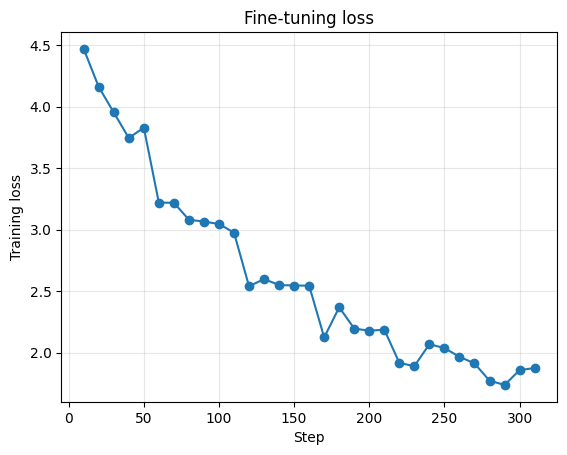

In [7]:
import matplotlib.pyplot as plt
logs = [(l["step"], l["loss"]) for l in trainer.state.log_history if "loss" in l]
plt.plot(*zip(*logs), marker="o")
plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title("Fine-tuning loss"); plt.grid(alpha=.3)
plt.savefig("training_loss.png", dpi=120); plt.show()

## 6. Fine-tuned model output (same prompt, same seed)

In [8]:
ft_model = GPT2LMHeadModel.from_pretrained("gpt2-captain-log").to(device)
ft_outputs = generate(ft_model)

for i, t in enumerate(ft_outputs, 1):
    print(f"--- FINE-TUNED sample {i} ---\n{t}\n")

with open("finetuned_model_output.txt", "w") as f:
    f.write(f"PROMPT: {PROMPT}\n\n" + "\n\n".join(f"[Sample {i}]\n{t}" for i, t in enumerate(ft_outputs, 1)))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

--- FINE-TUNED sample 1 ---
Today I woke up and found myself in the dark.
I was wearing nothing but a thin coat, grey trousers that would have washed ashore on any damp beachhead today evening. It seemed as though my feet had burned with ill weather for some weeks now. Yet at least one eye bore green gold; it spoke of an old friend who has died quietly beneath all our wings

--- FINE-TUNED sample 2 ---
Today I woke up and found myself dressed in the same old sailor's green coat as before.
"Hello, world," said Neptune once more; his wife held it proudly for me today. "I am a little strange to know everything about you." She opened my journal at noon with an open mouth like some kind of page from The Merchant Of Venice: letters sent home

--- FINE-TUNED sample 3 ---
Today I woke up and found myself in the cathedral's main hall.
The water was clear as day, but my spirits were low again today because of a bitter cold that crept into every part where we stood: tears streaming down our cheek

## 7. Before-and-after comparison
Side-by-side outputs plus simple measurable style indicators (nautical vocabulary, first-person usage, simile usage, sentence length).

In [9]:
import re
NAUTICAL = set("""sea ship ships sail sails wind waves wave captain crew deck mast anchor harbour harbor
storm tide tides fog sailor sailors helm helmsman voyage cape coast rigging port starboard bow hull
horizon ocean cargo log watch fathoms gale squall quay shore sailed sailing sailors""".split())

def stats(texts):
    words = re.findall(r"[a-zA-Z']+", " ".join(texts).lower())
    sents = [s for s in re.split(r"[.!?]+", " ".join(texts)) if s.strip()]
    return {
        "nautical word rate (%)": round(100 * sum(w in NAUTICAL for w in words) / max(len(words), 1), 2),
        "first-person 'I/we/my/our' (%)": round(100 * sum(w in {"i","we","my","our","us"} for w in words) / max(len(words), 1), 2),
        "similes ('like'/'as ... as') per 100 words": round(100 * (words.count("like") + len(re.findall(r"\bas \w+ as\b", " ".join(texts).lower()))) / max(len(words), 1), 2),
        "avg words per sentence": round(len(words) / max(len(sents), 1), 1),
    }

import pandas as pd
comparison = pd.DataFrame({"Base GPT-2": stats(base_outputs), "Fine-tuned GPT-2": stats(ft_outputs)})
display(comparison)

print("PROMPT:", PROMPT, "\n")
print("=== BASE (sample 1) ===\n", base_outputs[0], "\n")
print("=== FINE-TUNED (sample 1) ===\n", ft_outputs[0])

comparison.to_csv("style_comparison.csv")

,Base GPT-2,Fine-tuned GPT-2
nautical word rate (%),0.00,1.0
first-person 'I/we/my/our' (%),5.03,5.5
similes ('like'/'as ... as') per 100 words,0.63,1.0
avg words per sentence,17.70,22.2


PROMPT: Today I woke up and 

=== BASE (sample 1) ===
 Today I woke up and looked around the room, there was something in my dress. It's a very nice little necklace of some sort (she didn't know where to find it). The front cover is really good with no scratches or things that may be exposed but not too bad for me!
I took out an old piece from one pocket while keeping all two pieces on 

=== FINE-TUNED (sample 1) ===
 Today I woke up and found myself in the dark.
I was wearing nothing but a thin coat, grey trousers that would have washed ashore on any damp beachhead today evening. It seemed as though my feet had burned with ill weather for some weeks now. Yet at least one eye bore green gold; it spoke of an old friend who has died quietly beneath all our wings


## 8. Analysis: differences in style

> **Fill this in after running the notebook**, using your own generated samples. Points to look for (check them against your real output before submitting):

1. **Vocabulary / topic:** the base model drifts toward generic modern or news-like text, while the fine-tuned model should use nautical vocabulary (*ship, crew, tide, anchor, helm*).
2. **Voice and register:** the fine-tuned model should adopt a first-person, formal, journal-like voice ("I have…", "We weighed anchor…"), where the base model's voice varies.
3. **Figurative language / sentence shape:** the training data uses similes ("grey as an old nail") and long, comma-joined sentences. Check whether the fine-tuned output does the same.

**Limitations:** with only ~200 lines, the model may repeat phrases from the training set (overfitting). Fewer epochs or a lower learning rate reduce this.

## 9. Files to submit
`raw_dataset.txt` (original), `clean_dataset.txt`, `base_model_output.txt`, `finetuned_model_output.txt`, `style_comparison.csv`, `training_loss.png`, this notebook, and the `gpt2-captain-log/` checkpoint folder.

In [10]:
import shutil
shutil.make_archive("gpt2-captain-log", "zip", "gpt2-captain-log")
try:
    from google.colab import files
    for f in ["raw_dataset.txt","clean_dataset.txt","base_model_output.txt","finetuned_model_output.txt",
              "style_comparison.csv","training_loss.png","gpt2-captain-log.zip"]:
        files.download(f)
except ImportError:
    print("Not on Colab - files are in the current folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>